# Sprint 4: Validación Final y Exportación de Modelos

En este notebook evaluamos el modelo final Stacking Classifier en el conjunto de prueba (test set) por primera y única vez. Calculamos intervalos de confianza con Bootstrap y comparamos su rendimiento contra el modelo baseline Random Forest del Sprint 3.

In [1]:
import sys
sys.path.append("../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Cargar conjunto de prueba
df = pd.read_csv("../data/processed/features_data.csv")
X = df.drop(columns=['attrition'])
y = df['attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X_test: (2800, 21), y_test: (2800,)


In [3]:
# Cargar modelo baseline y final
baseline_model = joblib.load("../models/baseline_rf.pkl")
best_model = joblib.load("../models/final_model.pkl")


=== Classification Report: Stacking Classifier ===
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      2368
           1       0.15      0.15      0.15       432

    accuracy                           0.74      2800
   macro avg       0.50      0.50      0.50      2800
weighted avg       0.74      0.74      0.74      2800

AUC-ROC: 0.497


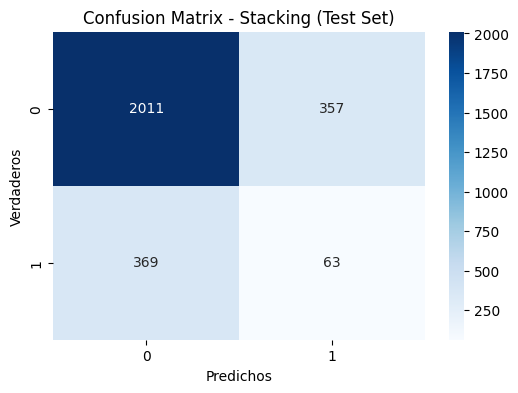

In [4]:
# Evaluación del modelo Stacking final en el test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("=== Classification Report: Stacking Classifier ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Stacking (Test Set)')
plt.ylabel('Verdaderos')
plt.xlabel('Predichos')
plt.show()


In [5]:
# Intervalos de confianza mediante Bootstrap
def bootstrap_metric(y_true, y_pred_prob, metric_fn, n=1000):
    scores = []
    y_true_np = np.array(y_true)
    for _ in range(n):
        idx = np.random.choice(len(y_true_np), len(y_true_np), replace=True)
        scores.append(metric_fn(y_true_np[idx], y_pred_prob[idx]))
    return np.percentile(scores, [2.5, 97.5])

ci = bootstrap_metric(y_test, y_proba, roc_auc_score)
print(f"AUC-ROC 95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")


AUC-ROC 95% CI: [0.467, 0.527]


In [6]:
# Tabla comparativa de Baseline vs Final
y_pred_base = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

p_base, r_base, f_base, _ = precision_recall_fscore_support(y_test, y_pred_base, average='macro', zero_division=0)
auc_base = roc_auc_score(y_test, y_proba_base)

p_final, r_final, f_final, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
auc_final = roc_auc_score(y_test, y_proba)

comparison = pd.DataFrame({
    'Metrica': ['F1 Macro', 'AUC-ROC', 'Recall Macro', 'Precision Macro'],
    'Baseline (Sprint 3)': [f_base, auc_base, r_base, p_base],
    'Tuned (Sprint 4)': [f_final, auc_final, r_final, p_final],
})

comparison['Mejora (%)'] = (
    (comparison['Tuned (Sprint 4)'] - comparison['Baseline (Sprint 3)'])
    / (comparison['Baseline (Sprint 3)'] + 1e-9)
    * 100
).round(1)

styled_comparison = comparison.style.highlight_max(
    subset=['Tuned (Sprint 4)'],
    color='lightgreen'
).format({"Baseline (Sprint 3)": "{:.3f}", "Tuned (Sprint 4)": "{:.3f}", "Mejora (%)": "{:.1f}%"})

display(styled_comparison)


,Metrica,Baseline (Sprint 3),Tuned (Sprint 4),Mejora (%)
0,F1 Macro,0.458,0.497,8.6%
1,AUC-ROC,0.496,0.497,0.2%
2,Recall Macro,0.500,0.498,-0.5%
3,Precision Macro,0.423,0.497,17.6%


In [7]:
# Copiar artefactos finales y muestras para Dashboard y API
Path("../dashboard").mkdir(parents=True, exist_ok=True)
shutil.copy("../models/final_model.pkl", "../dashboard/final_model.pkl")

Path("../handoff/model/final").mkdir(parents=True, exist_ok=True)
shutil.copy("../models/final_model.pkl", "../handoff/model/final/model.pkl")

Path("../handoff/model/preproc").mkdir(parents=True, exist_ok=True)
shutil.copy("../models/preprocessing_pipeline.pkl", "../handoff/model/preproc/pipeline.pkl")

# Guardar conjuntos de datos necesarios para SHAP y pruebas en el Dashboard
X_test.to_csv("../dashboard/X_test_sample.csv", index=False)
X_train.sample(500, random_state=42).to_csv("../dashboard/X_background.csv", index=False)
print("Archivos copiados con éxito a dashboard y handoff.")


Archivos copiados con éxito a dashboard y handoff.
